# Economy Forecasting Experiments

This notebook keeps the original economy-notebook structure: one section per dataset, one forecasting run per section, plots first and summary tables after.

The notebook now runs on the repository's Qwen-native mainline. For the remote LLM path, the default autotune objective is `validation_metric`, which preserves the original validation-based model-selection idea without reintroducing legacy OpenAI completion scoring.


In [1]:
import os
import random
from pathlib import Path

os.environ['OMP_NUM_THREADS'] = '4'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_squared_error, r2_score

from configs.runtime import describe_runtime
from experiments.model_defaults import (
    DEFAULT_LLMTIME_HYPERS,
    DEFAULT_PROMPTCAST_HYPERS,
    DEFAULT_REMOTE_MODEL,
    describe_model_capabilities,
)
from models.darts import get_arima_predictions_data
from models.llmtime import get_llmtime_predictions_data
from models.promptcast import get_promptcast_predictions_data
from models.utils import grid_iter
from models.validation_likelihood_tuning import get_autotuned_predictions_data
import warnings

warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

describe_runtime()
describe_model_capabilities(DEFAULT_REMOTE_MODEL)


D:\anaconda_py_package\Anaconda_envs\envs\llmtime\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'model': 'qwen-plus',
 'supports_sampling': True,
 'supports_nll_scoring': False,
 'supported_autotune_modes': ['validation_metric', 'disabled'],
 'default_autotune_mode': 'validation_metric'}

In [2]:
RANDOM_SEED = 7
TEST_FRAC = 0.2
MAX_CONTEXT_POINTS = 500
REMOTE_NUM_SAMPLES = 10
NOTEBOOK_PARALLEL = False
INCLUDE_PROMPTCAST = False
ECONOMY_DATA_DIR = Path('datasets/economy')

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def build_model_registry(include_promptcast=INCLUDE_PROMPTCAST):
    qwen_hypers = dict(DEFAULT_LLMTIME_HYPERS)
    promptcast_hypers = dict(DEFAULT_PROMPTCAST_HYPERS)
    arima_hypers = dict(p=[12, 20, 30], d=[1, 2], q=[0, 1, 2])

    model_hypers = {
        'LLMTime Qwen': qwen_hypers,
        'ARIMA': arima_hypers,
    }
    model_predict_fns = {
        'LLMTime Qwen': get_llmtime_predictions_data,
        'ARIMA': get_arima_predictions_data,
    }
    model_names = ['LLMTime Qwen', 'ARIMA']

    if include_promptcast:
        model_hypers['PromptCast Qwen'] = promptcast_hypers
        model_predict_fns['PromptCast Qwen'] = get_promptcast_predictions_data
        model_names.insert(1, 'PromptCast Qwen')

    return model_hypers, model_predict_fns, model_names

model_hypers, model_predict_fns, model_names = build_model_registry()
pd.DataFrame(
    [
        {
            'model_name': model_name,
            'autotune_mode': model_hypers[model_name].get('autotune_mode', 'nll'),
            'num_samples': REMOTE_NUM_SAMPLES,
        }
        for model_name in model_names
    ]
)


,model_name,autotune_mode,num_samples
0,LLMTime Qwen,validation_metric,10
1,ARIMA,nll,10


In [3]:
def load_economy_series(ds_name, data_dir=ECONOMY_DATA_DIR):
    csv_path = data_dir / f'{ds_name}.csv'
    if not csv_path.exists():
        raise FileNotFoundError(f'Missing economy dataset: {csv_path}')
    dataframe = pd.read_csv(csv_path)
    dataframe = dataframe.iloc[28:].copy()
    timestamps = pd.to_datetime(dataframe.iloc[:, 0], format='%m/%Y', errors='coerce')
    values = pd.to_numeric(dataframe.iloc[:, 1], errors='coerce').astype(float)
    valid_mask = values.notna() & timestamps.notna()
    series = pd.Series(values.loc[valid_mask].to_numpy(), index=timestamps.loc[valid_mask], name=ds_name)
    return series.sort_index()


def maybe_trim_series(series, ds_name, max_points=MAX_CONTEXT_POINTS, seed=RANDOM_SEED):
    if len(series) <= max_points:
        print(f'{ds_name}: using full history of {len(series)} points')
        return series
    rng = random.Random(f'{seed}:{ds_name}')
    offset = rng.randint(0, len(series) - max_points)
    print(
        f'{ds_name}: trimmed history from {len(series)} to {max_points} points '
        f'using deterministic offset {offset}'
    )
    return series.iloc[offset:offset + max_points]


def split_series(series, testfrac=TEST_FRAC):
    splitpoint = int(len(series) * (1 - testfrac))
    train = series.iloc[:splitpoint]
    test = series.iloc[splitpoint:]
    print(f'train length={len(train)}, test length={len(test)}, horizon={len(test)}')
    return train, test


def align_prediction_and_truth(test, pred_dict, model_name):
    pred = pred_dict.get('median')
    if pred is None:
        raise ValueError(f'{model_name} did not return a median forecast.')
    pred = np.asarray(pred, dtype=float).reshape(-1)
    truth = np.asarray(test.values, dtype=float).reshape(-1)

    raw_pred_len = len(pred)
    raw_truth_len = len(truth)
    if raw_pred_len != raw_truth_len:
        print(
            f'{model_name}: forecast length mismatch raw_pred_len={raw_pred_len}, '
            f'truth_len={raw_truth_len}; truncating to common prefix.'
        )
    common_len = min(raw_pred_len, raw_truth_len)
    pred = pred[:common_len]
    truth = truth[:common_len]
    index = test.index[:common_len]

    finite_mask = np.isfinite(pred) & np.isfinite(truth)
    if finite_mask.sum() != common_len:
        print(
            f'{model_name}: dropping {common_len - finite_mask.sum()} positions because '
            f'prediction/truth contains NaN or inf.'
        )
    pred = pred[finite_mask]
    truth = truth[finite_mask]
    index = index[finite_mask]

    pred_series = pd.Series(pred, index=index, name=f'{model_name}_pred')
    truth_series = pd.Series(truth, index=index, name='truth')
    alignment = {
        'raw_prediction_len': raw_pred_len,
        'raw_truth_len': raw_truth_len,
        'aligned_len': len(pred_series),
        'dropped_points': int(common_len - len(pred_series)),
        'short_prediction_or_padding': raw_pred_len < raw_truth_len,
    }
    return pred_series, truth_series, alignment


def compute_metrics(truth_series, pred_series, model_name):
    if len(truth_series) == 0:
        raise ValueError(f'{model_name}: no aligned points remain after NaN handling.')
    mse = float(mean_squared_error(truth_series.values, pred_series.values))
    if len(truth_series) < 2 or np.isclose(np.nanvar(truth_series.values), 0.0):
        print(f'{model_name}: R2 is undefined for this section because the aligned truth has near-zero variance.')
        r2 = np.nan
    else:
        r2 = float(r2_score(truth_series.values, pred_series.values))
    return {'MSE': mse, 'R2': r2}


def plot_preds(train, test, pred_series, model_name, metrics, ds_name):
    plt.figure(figsize=(8, 6), dpi=100)
    plt.title(f'{ds_name} | {model_name}')
    plt.plot(train.index, train.values, label='Train')
    plt.plot(test.index, test.values, label='Truth', color='black')
    plt.plot(pred_series.index, pred_series.values, label=model_name, color='purple')
    plt.legend(loc='upper left')
    metrics_text = (
        f"MSE: {metrics['MSE']:.4f}\nR2: {metrics['R2']:.4f}"
        if np.isfinite(metrics['R2'])
        else f"MSE: {metrics['MSE']:.4f}\nR2: nan"
    )
    plt.text(
        0.03,
        0.85,
        metrics_text,
        transform=plt.gca().transAxes,
        bbox=dict(facecolor='white', alpha=0.6),
    )
    plt.show()


def run_model(train, test, ds_name, model_name, model_hypers=model_hypers, model_predict_fns=model_predict_fns):
    hyper_grid = dict(model_hypers[model_name])
    if model_name.startswith('PromptCast'):
        hyper_grid['dataset_name'] = ds_name
    if model_name != 'ARIMA':
        horizon_budget = max(512, len(test) * 32)
        hyper_grid['max_new_tokens'] = max(int(hyper_grid.get('max_new_tokens', 0) or 0), horizon_budget)
        hyper_grid['max_retries_on_short'] = max(int(hyper_grid.get('max_retries_on_short', 0) or 0), 3)
    hypers = list(grid_iter(hyper_grid))
    num_samples = REMOTE_NUM_SAMPLES if model_name != 'ARIMA' else 100
    pred_dict = get_autotuned_predictions_data(
        train,
        test,
        hypers,
        num_samples,
        model_predict_fns[model_name],
        verbose=False,
        parallel=NOTEBOOK_PARALLEL,
    )
    pred_series, truth_series, alignment = align_prediction_and_truth(test, pred_dict, model_name)
    metrics = compute_metrics(truth_series, pred_series, model_name)
    plot_preds(train, test, pred_series, model_name, metrics, ds_name)
    return {
        'pred_dict': pred_dict,
        'pred_series': pred_series,
        'truth_series': truth_series,
        'alignment': alignment,
        'metrics': metrics,
    }


def out(train, test, ds_name, model_hypers=model_hypers, model_names=model_names):
    results = {}
    metric_rows = []
    for model in model_names:
        print(f'Running {ds_name} | {model}')
        model_result = run_model(train, test, ds_name, model)
        results[model] = model_result
        metric_rows.append(
            {
                'model': model,
                'MSE': model_result['metrics']['MSE'],
                'R2': model_result['metrics']['R2'],
                'autotune_mode': model_result['pred_dict'].get('autotune', {}).get('mode', 'fixed'),
                'aligned_points': model_result['alignment']['aligned_len'],
            }
        )
    results['metrics'] = pd.DataFrame(metric_rows).set_index('model').sort_values('MSE')
    return results


def run_economy_section(ds_name):
    series = load_economy_series(ds_name)
    series = maybe_trim_series(series, ds_name)
    train, test = split_series(series)
    print(f'{ds_name}: test start={test.index[0]!s}, test end={test.index[-1]!s}')
    results = out(train, test, ds_name)
    results['dataset_name'] = ds_name
    results['series'] = series
    results['train'] = train
    results['test'] = test
    return results


In [4]:
economy_results = {}


# Export_China_Monthly


Export_China_Monthly: using full history of 384 points
train length=307, test length=77, horizon=77
Export_China_Monthly: test start=2017-08-01 00:00:00, test end=2023-12-01 00:00:00
Running Export_China_Monthly | LLMTime Qwen


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:14<00:00, 14.66s/it]


Retrying short completion 71 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 70 < 77 with max_new_tokens=4928 (attempt 1/3)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:31<00:00, 31.95s/it]

Retrying short completion 67 < 77 with max_new_tokens=4928 (attempt 1/3)


...

Retrying short completion 69 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 67 < 77 with max_new_tokens=4928 (attempt 1/3)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:19<00:00, 19.04s/it]


Retrying short completion 65 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 67 < 77 with max_new_tokens=4928 (attempt 1/3)


100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [02:08<00:00, 128.85s/it]


Retrying short completion 69 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 68 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 63 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 61 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 65 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 61 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 72 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 53 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 72 < 77 with max_new_tokens=4928 (attempt 2/3)
Retrying short completion 67 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 49 < 77 with max_new_tokens=4928 (attempt 1/3)
Retrying short completion 67 < 77 with max_new_tokens=4928 (attempt 2/3)


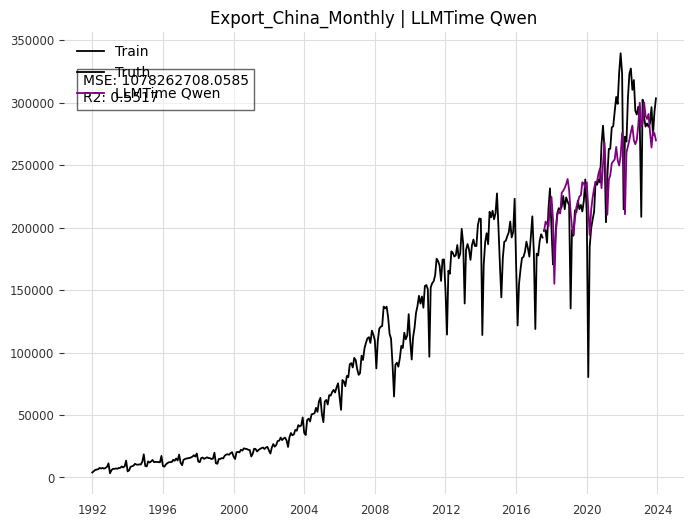

Running Export_China_Monthly | ARIMA


Hyperparameter search: 100%|███████████████████████████████████████████████████████████| 18/18 [01:04<00:00,  3.60s/it]


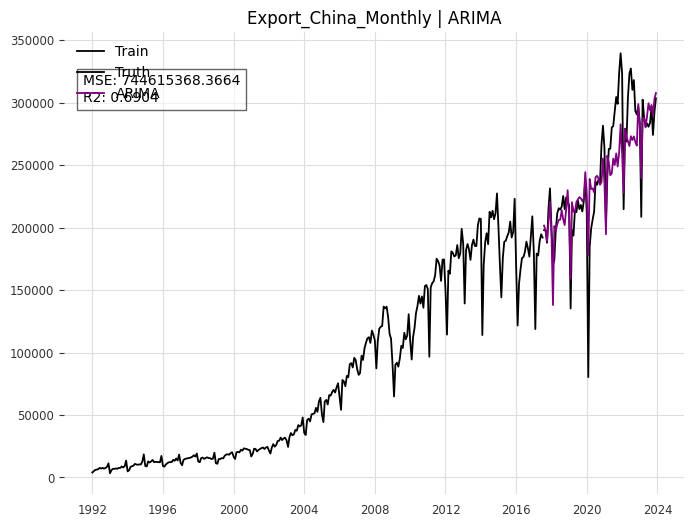

,MSE,R2,autotune_mode,aligned_points
model,,,,
ARIMA,7.446154e+08,0.690412,nll,77
LLMTime Qwen,1.078263e+09,0.551691,validation_metric,77


In [5]:
ds_name = 'Export_China_Monthly'
economy_results[ds_name] = run_economy_section(ds_name)
display(economy_results[ds_name]['metrics'])


# Export_HongKong_Monthly


Export_HongKong_Monthly: trimmed history from 776 to 500 points using deterministic offset 116
train length=400, test length=100, horizon=100
Export_HongKong_Monthly: test start=2002-06-01 00:00:00, test end=2010-09-01 00:00:00
Running Export_HongKong_Monthly | LLMTime Qwen


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:51<00:00, 51.89s/it]


Retrying short completion 93 < 100 with max_new_tokens=6400 (attempt 1/3)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:28<00:00, 28.11s/it]


Retrying short completion 77 < 100 with max_new_tokens=6400 (attempt 1/3)
Retrying short completion 75 < 100 with max_new_tokens=6400 (attempt 1/3)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:41<00:00, 41.52s/it]


Retrying short completion 76 < 100 with max_new_tokens=6400 (attempt 1/3)


100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [02:36<00:00, 156.44s/it]


Retrying short completion 83 < 100 with max_new_tokens=6400 (attempt 1/3)
Retrying short completion 68 < 100 with max_new_tokens=6400 (attempt 1/3)
Retrying short completion 81 < 100 with max_new_tokens=6400 (attempt 1/3)
Retrying short completion 79 < 100 with max_new_tokens=6400 (attempt 1/3)
Retrying short completion 90 < 100 with max_new_tokens=6400 (attempt 1/3)
Retrying short completion 90 < 100 with max_new_tokens=6400 (attempt 1/3)
Retrying short completion 82 < 100 with max_new_tokens=6400 (attempt 1/3)
Retrying short completion 70 < 100 with max_new_tokens=6400 (attempt 1/3)
Retrying short completion 91 < 100 with max_new_tokens=6400 (attempt 1/3)
Retrying short completion 91 < 100 with max_new_tokens=6400 (attempt 1/3)


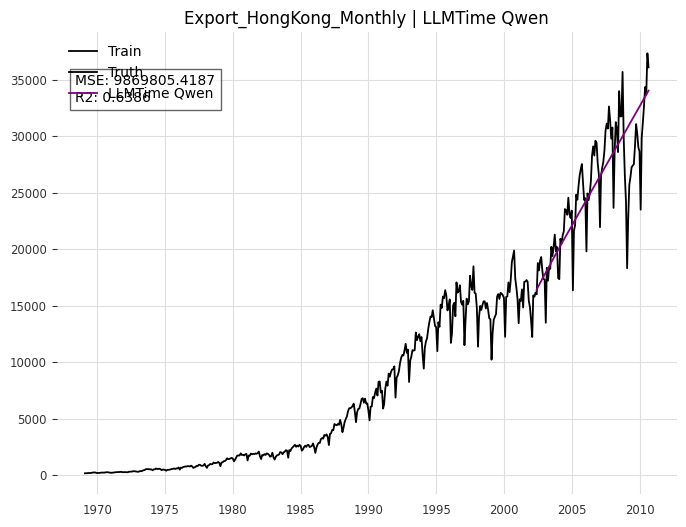

Running Export_HongKong_Monthly | ARIMA


Hyperparameter search: 100%|███████████████████████████████████████████████████████████| 18/18 [01:15<00:00,  4.21s/it]


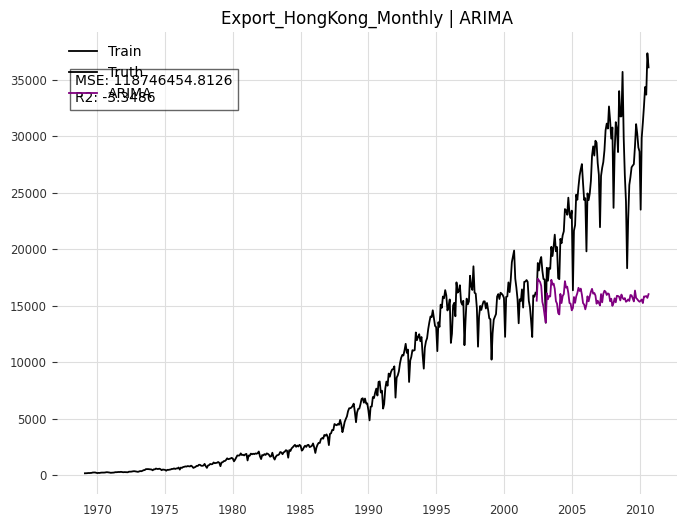

,MSE,R2,autotune_mode,aligned_points
model,,,,
LLMTime Qwen,9.869805e+06,0.638563,validation_metric,100
ARIMA,1.187465e+08,-3.348551,nll,100


In [6]:
ds_name = 'Export_HongKong_Monthly'
economy_results[ds_name] = run_economy_section(ds_name)
display(economy_results[ds_name]['metrics'])


# Export_France_Monthly


In [ ]:
ds_name = 'Export_France_Monthly'
economy_results[ds_name] = run_economy_section(ds_name)
display(economy_results[ds_name]['metrics'])


# Export_UK_Monthly


In [ ]:
ds_name = 'Export_UK_Monthly'
economy_results[ds_name] = run_economy_section(ds_name)
display(economy_results[ds_name]['metrics'])


# Export_American_Monthly


In [ ]:
ds_name = 'Export_American_Monthly'
economy_results[ds_name] = run_economy_section(ds_name)
display(economy_results[ds_name]['metrics'])


# Export_Japan_Monthly


In [ ]:
ds_name = 'Export_Japan_Monthly'
economy_results[ds_name] = run_economy_section(ds_name)
display(economy_results[ds_name]['metrics'])


## Economy Summary

这里汇总大陆和中国香港的数据，同时在 Qwen 原生路径下添加了对齐后的均方误差 (MSE) 和决定系数 (R²) 值，以便于查看。
因为api token消耗问题，后面四个先不运行，如果token足够可以运行之后汇总所有数据。


In [7]:
economy_summary = pd.concat(
    [
        result['metrics'].assign(dataset=ds_name)
        for ds_name, result in economy_results.items()
    ]
).reset_index().set_index(['dataset', 'model']).sort_values(['dataset', 'MSE'])
display(economy_summary)


MSE        R2  \
dataset                 model                                  
Export_China_Monthly    ARIMA         7.446154e+08  0.690412   
                        LLMTime Qwen  1.078263e+09  0.551691   
Export_HongKong_Monthly LLMTime Qwen  9.869805e+06  0.638563   
                        ARIMA         1.187465e+08 -3.348551   

                                          autotune_mode  aligned_points  
dataset                 model                                            
Export_China_Monthly    ARIMA                       nll              77  
                        LLMTime Qwen  validation_metric              77  
Export_HongKong_Monthly LLMTime Qwen  validation_metric             100  
                        ARIMA                       nll             100

In [8]:
ds_name = 'Export_China_Monthly'
if ds_name not in economy_results:
    print(f"Run the {ds_name} section first so this diagnostic can inspect the saved result.")
else:
    china_result = economy_results[ds_name]
    qwen_result = china_result['LLMTime Qwen']
    arima_result = china_result['ARIMA']

    truth = qwen_result['truth_series'].to_numpy(dtype=float)
    pred = qwen_result['pred_series'].to_numpy(dtype=float)
    raw_lengths = qwen_result['pred_dict'].get('info', {}).get('RawPredictionLengths')
    has_short = qwen_result['pred_dict'].get('info', {}).get('HasShortPrediction')

    full_horizon = len(truth)
    parsed_full = bool(raw_lengths) and all(length == full_horizon for lengths in raw_lengths for length in lengths)
    truth_min, truth_max = float(np.nanmin(truth)), float(np.nanmax(truth))
    pred_min, pred_max = float(np.nanmin(pred)), float(np.nanmax(pred))
    truth_median = float(np.nanmedian(np.abs(truth)))
    pred_median = float(np.nanmedian(np.abs(pred)))
    scale_ratio = pred_median / max(truth_median, 1e-12)

    diagnosis = pd.DataFrame(
        [
            {'check': 'Aligned forecast length', 'value': qwen_result['alignment']['aligned_len'], 'expected': full_horizon},
            {'check': 'All parsed sample lengths', 'value': raw_lengths, 'expected': f'{full_horizon} for every sample'},
            {'check': 'Qwen truth range', 'value': f'[{truth_min:,.1f}, {truth_max:,.1f}]', 'expected': 'Observed test series scale'},
            {'check': 'Qwen pred range', 'value': f'[{pred_min:,.1f}, {pred_max:,.1f}]', 'expected': 'Should be comparable to truth if scale is captured'},
            {'check': 'Median abs(pred) / abs(truth)', 'value': f'{scale_ratio:.6f}', 'expected': 'Not near zero if scale is learned'},
            {'check': 'Qwen MSE', 'value': f"{qwen_result['metrics']['MSE']:.3e}", 'expected': 'Compare with ARIMA'},
            {'check': 'ARIMA MSE', 'value': f"{arima_result['metrics']['MSE']:.3e}", 'expected': 'Sanity baseline on same split'},
        ]
    )
    display(diagnosis)

    if qwen_result['alignment']['aligned_len'] != full_horizon:
        verdict = 'Length/alignment is still broken, so treat this as a pipeline issue first.'
    elif not parsed_full or bool(has_short):
        verdict = 'Generation still depended on short or repaired samples, so the result mixes model weakness with decoding instability.'
    elif pred_max < 0.1 * truth_max and scale_ratio < 0.1:
        verdict = (
            'Parsing and length look normal, but the forecast scale collapses far below the true series scale. '
            'This points more to a model/method limitation on this economy series than to an obvious code bug.'
        )
    else:
        verdict = (
            'Nothing obvious is broken in the pipeline; if the curve is still poor, it is more likely due to model fit than a clear implementation error.'
        )

    print(verdict)


,check,value,expected
0,Aligned forecast length,77,77
1,All parsed sample lengths,"[[77, 77, 77, 77, 77, 77, 77, 77, 77, 77]]",77 for every sample
2,Qwen truth range,"[80,379.3, 339,662.3]",Observed test series scale
3,Qwen pred range,"[155,064.5, 300,324.4]",Should be comparable to truth if scale is capt...
4,Median abs(pred) / abs(truth),1.003468,Not near zero if scale is learned
5,Qwen MSE,1.078e+09,Compare with ARIMA
6,ARIMA MSE,7.446e+08,Sanity baseline on same split


Nothing obvious is broken in the pipeline; if the curve is still poor, it is more likely due to model fit than a clear implementation error.
